# Baging pour l'identification des réseaux moléculaires

### Test du vote avec l'algorithme `MCLA`

In [ ]:
!pip install kahypar

In [8]:
import numpy as np
from utils.ClusterEnsembles.ClusterEnsembles import mcla

label1 = np.array([1, 1, 1, 2, 2, 3, 3])

label2 = np.array([2, 2, 2, 3, 3, 1, 1])

label3 = np.array([4, 4, 2, 2, 3, 3, 3])

label4 = np.array([1, 2, np.nan, 1, 2, np.nan, np.nan]) # `np.nan`: missing value

labels = np.array([label1, label2, label3, label4])

mcla(labels,2,0)

array([1, 1, 1, 0, 0, 0, 0])

### Test du bagging sur la dataset `MSRCV1` avec pour weak-learner `MCLES`

In [9]:
from datasets.load import load_msrcv1

dataset = load_msrcv1("datasets/")
dataset.keys()

dict_keys(['X', 'Y', 'name'])

In [11]:
from bagging import bagging_prime
k = 7
r = bagging_prime(dataset["X"], k)

/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted P to scipy.sparse.csc.csc_matrix
For best performance, build P as a scipy.sparse.csc_matrix rather than as a numpy.ndarray
  warnings.warn(
/home/mbe/anaconda3/lib/python3.10/site-packages/qpsolvers/conversions/ensure_sparse_matrices.py:38: UserWarning: Converted A to scipy.sparse.csc.csc_matrix
For best performance, build A as a scipy.sparse.csc

In [13]:
from metriques import clusteringMeasure

clusteringMeasure(dataset["Y"], r)

{'ACC': 0.7857142857142857,
 'NMI': 0.7258446007538624,
 'PUR': 0.7857142857142857}

### visualisation des réseaux moléculaires de madbyte

Sur les données de test de références de madbyte

In [14]:
from utils.madbyte.own import madbyte_clusters_begin
from utils.utils import generate_colors_clusters
from utils.madbyte.plot import visualize_graph_madbyte

In [15]:
import networkx as nx

G_all = nx.read_graphml("./test_association_network_all.graphml")
G_sim = nx.read_graphml("./test_similarity_network_network.graphml")
G_hybrid = nx.read_graphml("./test_hybrid_network.graphml")

In [16]:
clusters_mol = madbyte_clusters_begin(G_hybrid)
clusters_mol

{'HND_Thiamphenicol': 0,
 'HND_Chloramphenicol': 0,
 'HND_Roxithromycin': 1,
 'HND_Erythromycin': 1,
 'HND_Azithromycin': 1}

In [19]:
colors = generate_colors_clusters(2, clusters_mol, exclude_colors=["#0ffbff", "#d3d7cf"])
colors

{'HND_Thiamphenicol': '#0ABE22',
 'HND_Chloramphenicol': '#0ABE22',
 'HND_Roxithromycin': '#FA7271',
 'HND_Erythromycin': '#FA7271',
 'HND_Azithromycin': '#FA7271'}

In [20]:
networks_madbyte = [G_all, G_sim, G_hybrid]
for G in networks_madbyte:
    visualize_graph_madbyte(G, colors_clusters=colors)

Loading BokehJS ...

Loading BokehJS ...

Loading BokehJS ...

#### visualisation des réseaux au cas où l'API bokeh n'est pas accéssible

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

img_all = np.asarray(Image.open("./test_all_madbyte_bokeh_plot.png"))
img_sim = np.asarray(Image.open("./test_sim_madbyte_bokeh_plot.png"))
img_hybrid = np.asarray(Image.open("./test_hybrid_madbyte_bokeh_plot.png"))

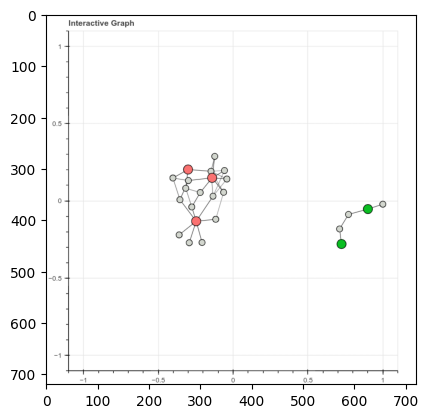

In [31]:
plt.imshow(img_all)

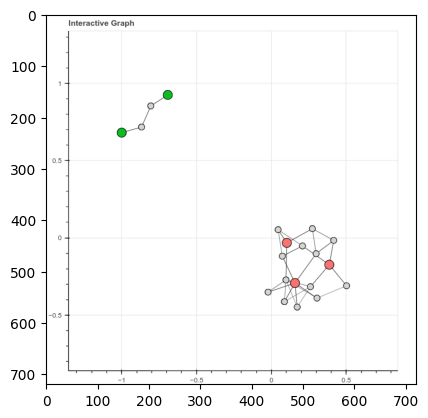

In [32]:
plt.imshow(img_sim)

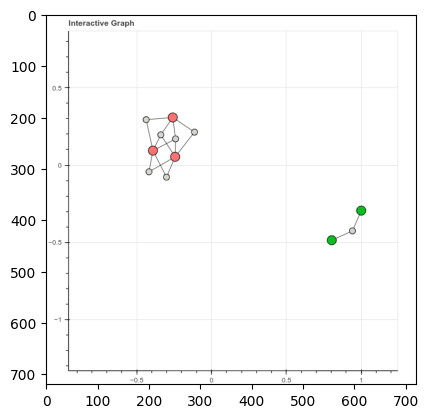

In [33]:
plt.imshow(img_hybrid)